In [1]:
drds <- "./00RDS/"
dout <- "./01figure1/"
setwd("./01figure1/")

In [3]:
i <- 0
for (s in Sys.glob(file.path(drds,"*_satge_cellsubtype.RDS"))){
    i <- i+1
    key <- gsub("_satge_cellsubtype.RDS", "",basename(s))
    rds <- paste0(drds, key,"_satge_cellsubtype.RDS")
    sp <- readRDS(rds)
    k <- as.data.frame(table(sp@meta.data$first_type))
    colnames(k) <- c("celltype",key)
    if(i==1){
        mer <- k
    }
    else{
        mer <- merge(mer,k)
    }
}

In [9]:
rownames(mer) <- mer$celltype
mer <- mer[,-1]

In [10]:
mer

,SS200000005TL_F3_1,SS200000005TL_F3_2,SS200000005TL_F4_1,SS200000005TL_F4_2,SS200000148TL_B3_1,SS200000148TL_B3_2,SS200000162BL_F3_1,SS200000162BL_F3_2,SS200000170BL_A6_1,SS200000170BL_A6_2,⋯,SS200000709TR_E1_1,SS200000709TR_E1_2,SS200000709TR_E3_1,SS200000709TR_E3_2,SS200000709TR_E4_1,SS200000709TR_E4_2,SS200000709TR_E6_1,SS200000709TR_E6_2,SS200000709TR_F3_1,SS200000709TR_F3_2
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
EC,1105,1040,754,647,367,102,398,372,284,648,⋯,703,300,256,350,201,382,634,282,674,506
Fibroblast,1406,1230,982,863,1192,723,1058,938,1301,1526,⋯,1778,1092,640,998,655,1096,1794,624,1429,1022
Immune,91,57,51,40,27,23,25,49,18,72,⋯,54,17,24,15,14,6,24,103,23,146
Macrophage,2093,1639,3086,1353,741,317,284,282,308,257,⋯,3267,1263,199,210,183,287,3848,4456,2858,4086
Modulated_SMC,888,896,1142,376,456,207,644,546,595,655,⋯,2180,642,167,414,135,370,1851,1823,1008,1599
SMC,4253,5753,4855,3512,7346,3428,4643,4298,6836,6368,⋯,3077,1939,1142,2830,712,2245,2460,804,1758,1261


In [11]:
#####summary
m <- as.data.frame(t(mer))
m <- subset(m,select = c("Fibroblast","SMC","Modulated_SMC","Macrophage","Immune","EC"))

In [12]:
m1 <- as.data.frame(t(m))
mer1 <- m1

In [13]:
mer2 <- as.data.frame(sapply((mer1),prop.table))
rownames(mer2) <- rownames(mer1)

In [14]:
group <- read.csv("../new1.csv",row.names = 1)####tableS1

In [15]:
group1 <- subset(group,subset = sample=="save")

In [16]:
mer2 <- subset(mer2,select = rownames(group1))

In [17]:
mer2$celltype <- rownames(mer2)

In [18]:
mer3 <- melt(mer2)
colnames(mer3) <- c("celltype","ID","percent")

Using celltype as id variables



In [ ]:
type <- group

In [21]:
mer3$week <- "NA"
for(i in unique(mer3$ID)){
    week <- type[which(rownames(type)==i),]$week
    mer3[which(mer3$ID==i),]$week <- as.character(week)
}

In [22]:
mer3$week <- str_replace(mer3$week,"con","N")

In [24]:
unique(mer3$celltype)

[1] "Fibroblast"    "SMC"           "Modulated_SMC" "Macrophage"   
[5] "Immune"        "EC"

In [25]:
mer3$celltype <- str_replace(mer3$celltype,"Fibroblast","Fibro")
mer3$celltype <- str_replace(mer3$celltype,"Macrophage","Mp")
mer3$celltype <- str_replace(mer3$celltype,"Modulated_SMC","MSMC")
mer3$celltype <- str_replace(mer3$celltype,"Immune","Tcell")

In [26]:
unique(mer3$celltype)
mer3$celltype <- factor(mer3$celltype,levels = c('Fibro','SMC','MSMC','Mp','Tcell','EC'))

[1] "Fibro" "SMC"   "MSMC"  "Mp"    "Tcell" "EC"

In [27]:
mycolor <- c("Mp"='#df65b0',"MSMC"="#A1CFFA",
                                 "SMC"='#1f78b4',"EC"='#238b45',"Fibro"="#8b4a4b",
                                 "Tcell"='#ce1256')

In [35]:
saveRDS(mer3,"./1f.RDS")

In [28]:
library(Rmisc)

Loading required package: plyr

------------------------------------------------------------------------------

You have loaded plyr after dplyr - this is likely to cause problems.
If you need functions from both plyr and dplyr, please load plyr first, then dplyr:
library(plyr); library(dplyr)

------------------------------------------------------------------------------


Attaching package: ‘plyr’


The following object is masked from ‘package:ggpubr’:

    mutate


The following objects are masked from ‘package:dplyr’:

    arrange, count, desc, failwith, id, mutate, rename, summarise,
    summarize




In [29]:
tgc <-summarySE(mer3, measurevar="percent", groupvars=c("week","celltype"))

In [30]:
order <- c("W20_N","W0","W2","W6","W10","W20")
tgc$week <- factor(tgc$week,levels = order)

In [31]:
# 带有标准误差线的折线图
# Standard error of the mean
p <- ggplot(tgc, aes(x=week, y=percent,color=celltype,group=celltype)) + 
    geom_errorbar(aes(ymin=percent-se, ymax=percent+se), width=.1) +scale_color_manual(values = mycolor)+labs(x="",y="")+
    geom_line(cex=0.8) +geom_point()+theme_classic()
pdf("celltype_weeek_st1.pdf",width = 6,height = 5)
print(p)
print(p+theme(axis.text.x = element_text(size=15,color = "black"),
         axis.text.y = element_text(size=15,colour = "black"))+theme(legend.position = "none"))
dev.off()

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


png 
  2

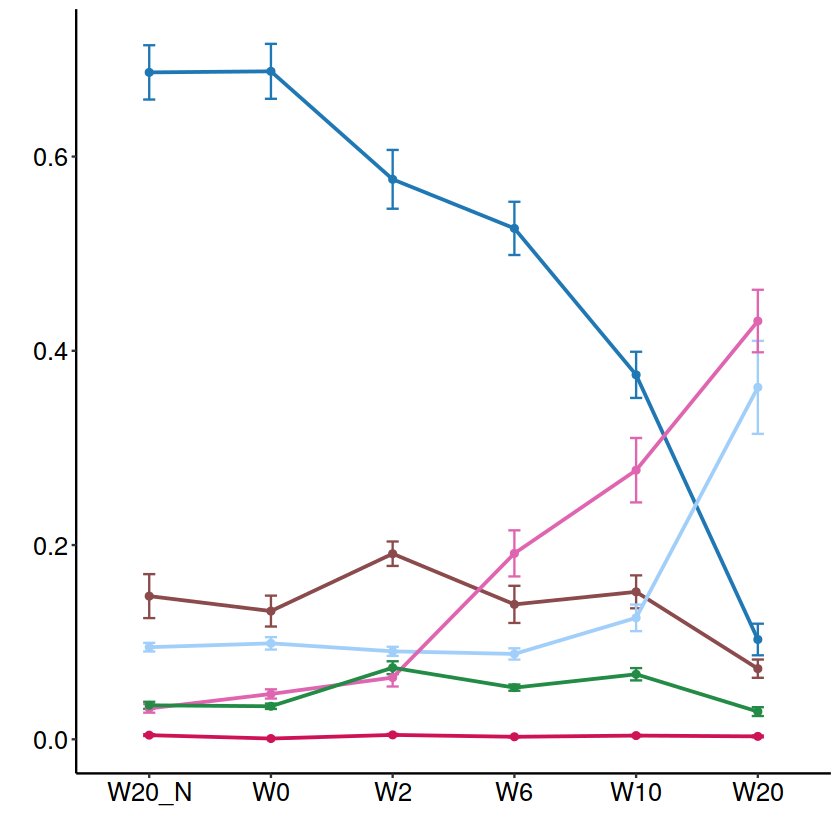

In [32]:
print(p+theme(axis.text.x = element_text(size=15,color = "black"),
         axis.text.y = element_text(size=15,colour = "black"))+theme(legend.position = "none"))

In [26]:
#####AD

In [3]:
cols <-c("GC-AA"="#FFCDEA","GC-AR"="#df65b0","GC-DA"="#ce1256","LC-AA"="#1f78b4","LC-AR"="#A1CFFA","LC-DA"="#EEF5FF")

In [36]:
i <- 0
for (s in Sys.glob(file.path(drds,"*_satge_cellsubtype.RDS"))){
    i <- i+1
    key <- gsub("_satge_cellsubtype.RDS", "",basename(s))
    rds <- paste0(drds, key,"_satge_cellsubtype.RDS")
    sp <- readRDS(rds)
    order <- c("GC-AA","GC-AR","GC-DA","LC-AA","LC-AR","LC-DA")
    sp@meta.data$AD <- factor(sp@meta.data$AD,levels = order)
    n=0
    for(d in unique(sp@meta.data$AD)){
        n=n+1
        sp1 <- subset(sp,subset = AD==d)
        k <- as.data.frame(table(sp1@meta.data$first_type))
        key1 <- paste0(key,d)
        colnames(k) <- c("celltype",key1)
        rownames(k) <- k$celltype
        k <- subset(k,select = key1)
        if(n==1){
            mer <- k
        }
        else{
            mer <- merge(mer,k,all = TRUE,by = 0)
            rownames(mer) <- mer$Row.names
            mer <- mer[,-1]
        }
    }
    if(i==1){
        mer1 <- mer
    }
    else{
        mer1 <- merge(mer1,mer,all = TRUE,by = 0)
        rownames(mer1) <- mer1$Row.names
        mer1 <- mer1[,-1]
    }
        
}

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from image to image_”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from image to image_”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from image to image_”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from image to image_”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from image to image_”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from image to image_”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from image to image_”
Warning message:
“Keys should be one or more alphanumeric characters followed by an unders

In [42]:
#####summary
m <- as.data.frame(t(mer1))
m <- subset(m,select = c("Fibroblast","SMC","Modulated_SMC","Macrophage","Immune","EC"))

In [43]:
m1 <- as.data.frame(t(m))
mer1 <- m1

In [44]:
mer2 <- as.data.frame(sapply((mer1),prop.table))
rownames(mer2) <- rownames(mer1)

In [45]:
group1 <- subset(group,subset = sample=="save")

In [46]:
mer2$celltype <- rownames(mer2)

In [47]:
mer3 <- melt(mer2)
colnames(mer3) <- c("celltype","ID","percent")

Using celltype as id variables



In [ ]:
substr(mer3$ID,1,18)

In [49]:
mer3$week <- "NA"
mer3$sample <-"NA"
mer3$chip_id <- substr(mer3$ID,1,18)
mer3$AD <- substr(mer3$ID,19,30)

In [50]:
for(i in unique(mer3$chip_id)){
    week <- type[which(rownames(type)==i),]$week
    sample <- type[which(rownames(type)==i),]$sample
    mer3[which(mer3$chip_id==i),]$week <- as.character(week)
    mer3[which(mer3$chip_id==i),]$sample <- as.character(sample)
}

In [51]:
mer3$week <- str_replace(mer3$week,"con","N")
unique(mer3$celltype)
mer3$celltype <- str_replace(mer3$celltype,"Fibroblast","Fibro")
mer3$celltype <- str_replace(mer3$celltype,"Macrophage","Mp")
mer3$celltype <- str_replace(mer3$celltype,"Modulated_SMC","MSMC")
mer3$celltype <- str_replace(mer3$celltype,"Immune","Tcell")

[1] "Fibroblast"    "SMC"           "Modulated_SMC" "Macrophage"   
[5] "Immune"        "EC"

In [52]:
unique(mer3$celltype)
mer3$celltype <- as.character(mer3$celltype)

[1] "Fibro" "SMC"   "MSMC"  "Mp"    "Tcell" "EC"

In [53]:
unique(mer3$AD)
unique(mer3$celltype)

[1] "LC-AR" "LC-AA" "GC-AR" "LC-DA" "GC-AA" "GC-DA"

[1] "Fibro" "SMC"   "MSMC"  "Mp"    "Tcell" "EC"

In [54]:
mer4 <- subset(mer3,subset = sample!="filter")

In [55]:
mer5 <- subset(mer4,subset = celltype=="MSMC")

In [56]:
cols <-c("GC-AA"="#A4DDD3","GC-AR"="#8D73BA","GC-DA"="#9FDAF7","LC-AA"="#F59B7B","LC-AR"="#D9DEE7","LC-DA"="#C74546")

In [57]:
tgc <-summarySE(mer5, measurevar="percent", groupvars=c("week","AD"))

In [58]:
order <- c("W20_N","W0","W2","W6","W10","W20")
tgc$week <- factor(tgc$week,levels = order)

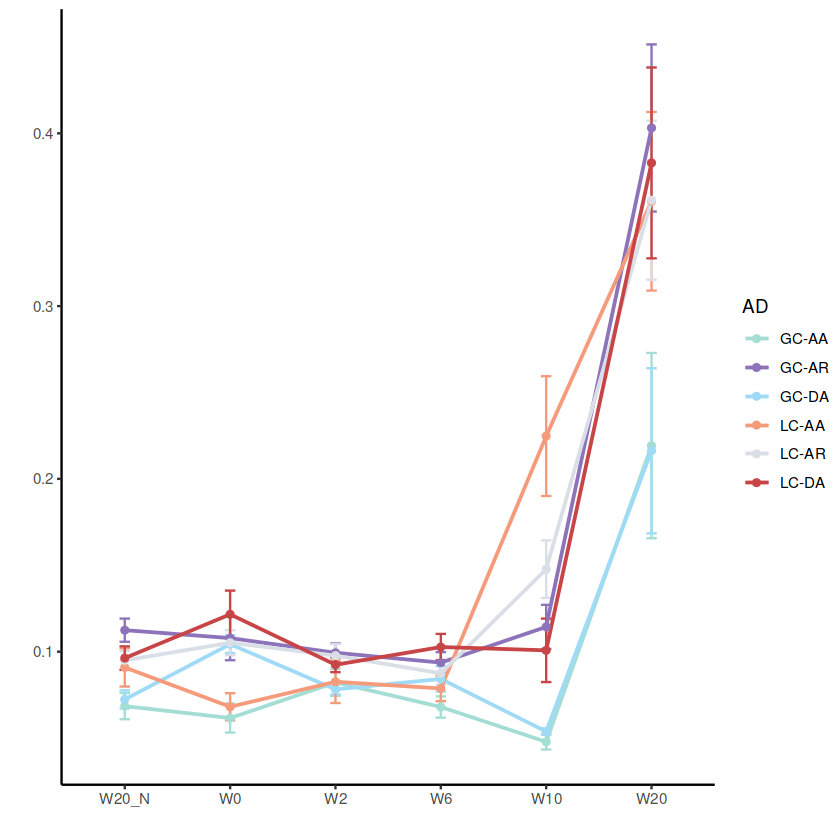

In [59]:

# Standard error of the mean
p1 <- ggplot(tgc, aes(x=week, y=percent,color=AD,group=AD)) + 
    geom_errorbar(aes(ymin=percent-se, ymax=percent+se), width=.1) +scale_color_manual(values = cols)+labs(x="",y="")+
    geom_line(cex=0.8) +geom_point()+theme_classic()
p1

In [60]:
cell <- c('Fibro','SMC','MSMC','Mp','Tcell','EC')

In [ ]:

print(p+ ylim(0, 0.8))
print(p+ ylim(0, 0.8)+theme(axis.text.x = element_text(size=15,color = "black"),
         axis.text.y = element_text(size=15,color = "black"))+theme(legend.position = "none"))
for(i in cell){
    mer5 <- subset(mer4,subset = celltype==i)
    tgc <-summarySE(mer5, measurevar="percent", groupvars=c("week","AD"))
    order <- c("W20_N","W0","W2","W6","W10","W20")
    tgc$week <- factor(tgc$week,levels = order)
    p1 <- ggplot(tgc, aes(x=week, y=percent,color=AD,group=AD)) + 
    geom_errorbar(aes(ymin=percent-se, ymax=percent+se), width=.1) +scale_color_manual(values = cols)+labs(x="week",y="percent",subtitle = i)+
    geom_line(cex=0.8) +geom_point()+theme_classic()
    print(p1+ ylim(0, 0.8))
    print(p1+ ylim(0, 0.8)+theme(axis.text.x = element_text(size=15,color = "black"),
         axis.text.y = element_text(size=15,color = "black"))+theme(legend.position = "none"))
}
#dev.off()

In [75]:
unique(mer4$celltype)
m <- subset(mer4,subset = celltype%in%c("SMC","MSMC","Mp"))

[1] "Fibro" "SMC"   "MSMC"  "Mp"    "Tcell" "EC"

In [76]:
saveRDS(m,"/DATA/User/liqian7/pienapple/07fn_add_coding/01figure1/1f_2.RDS")

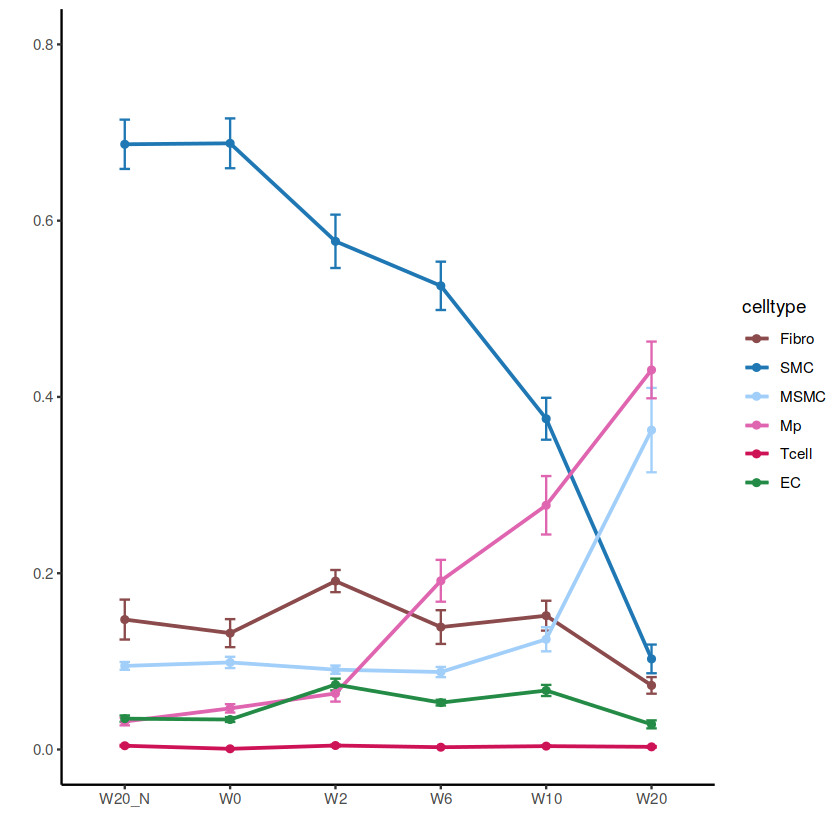

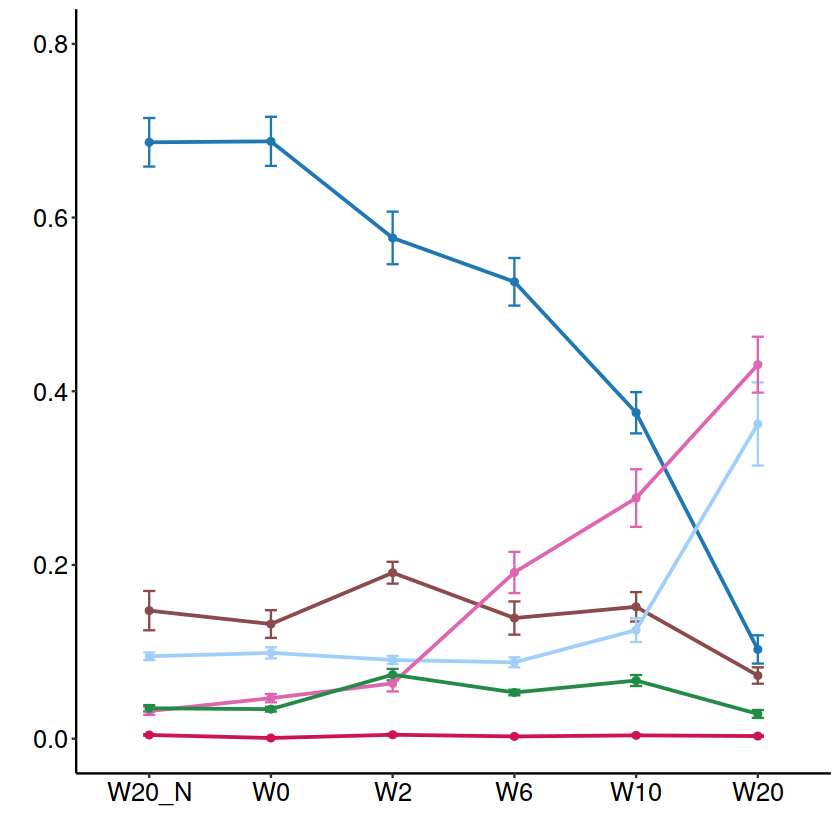

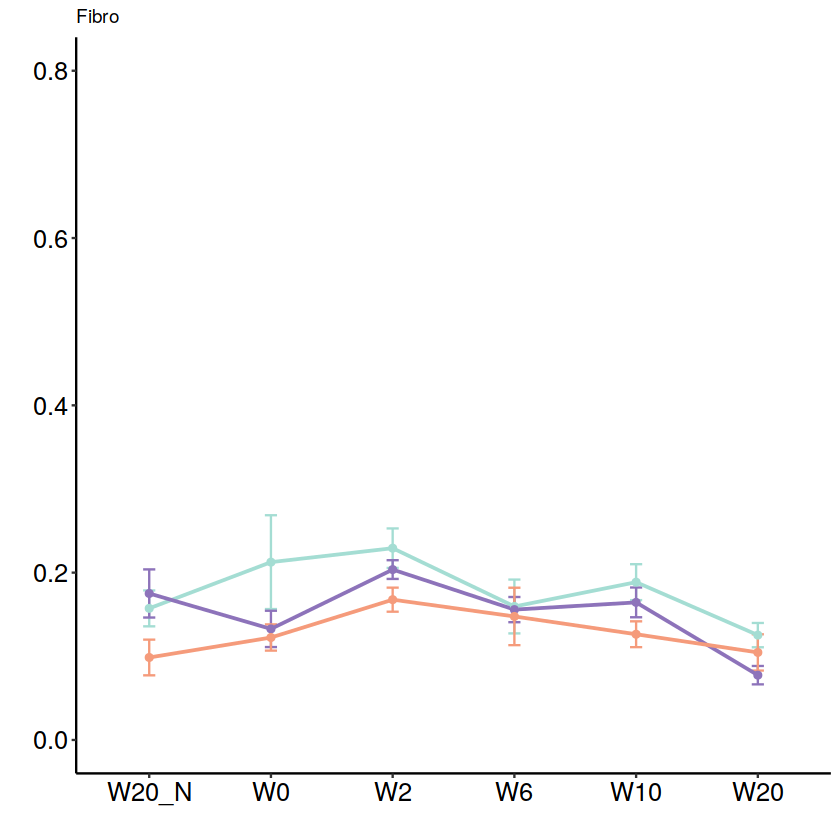

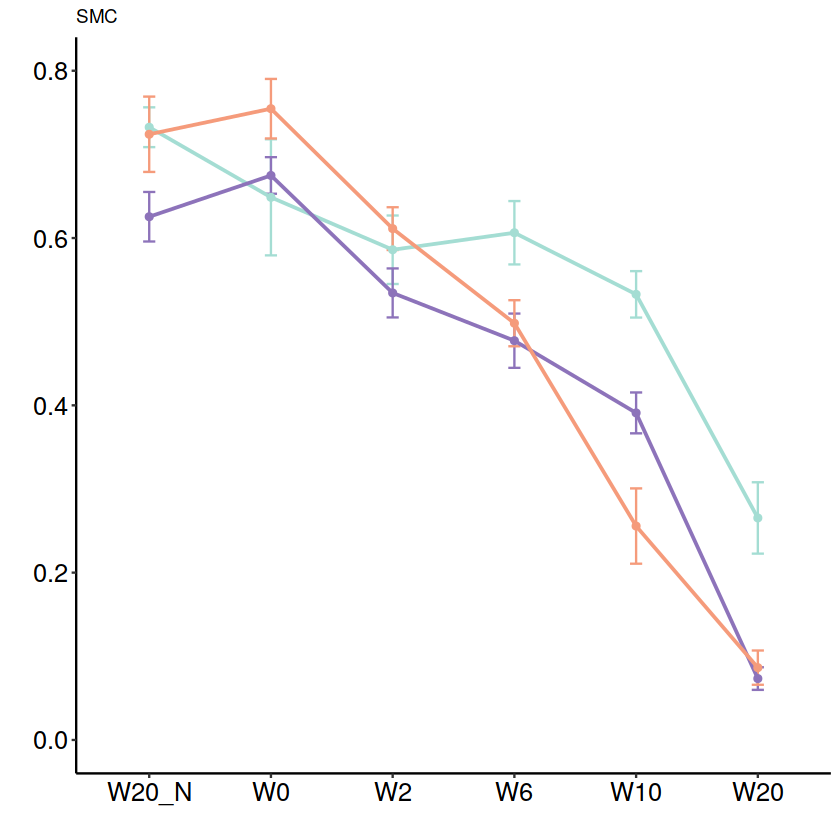

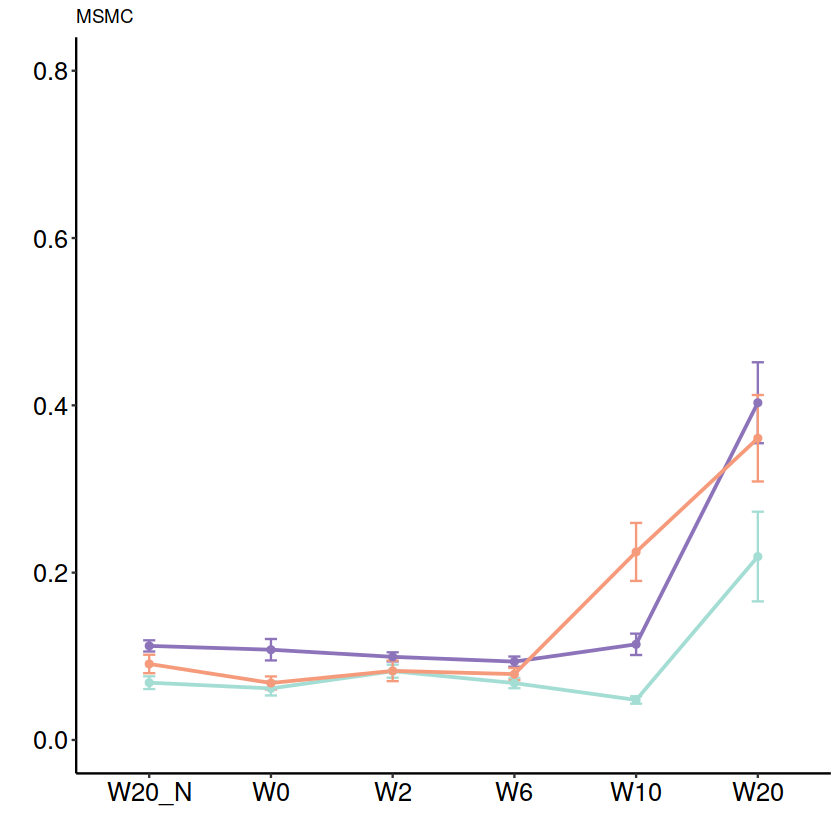

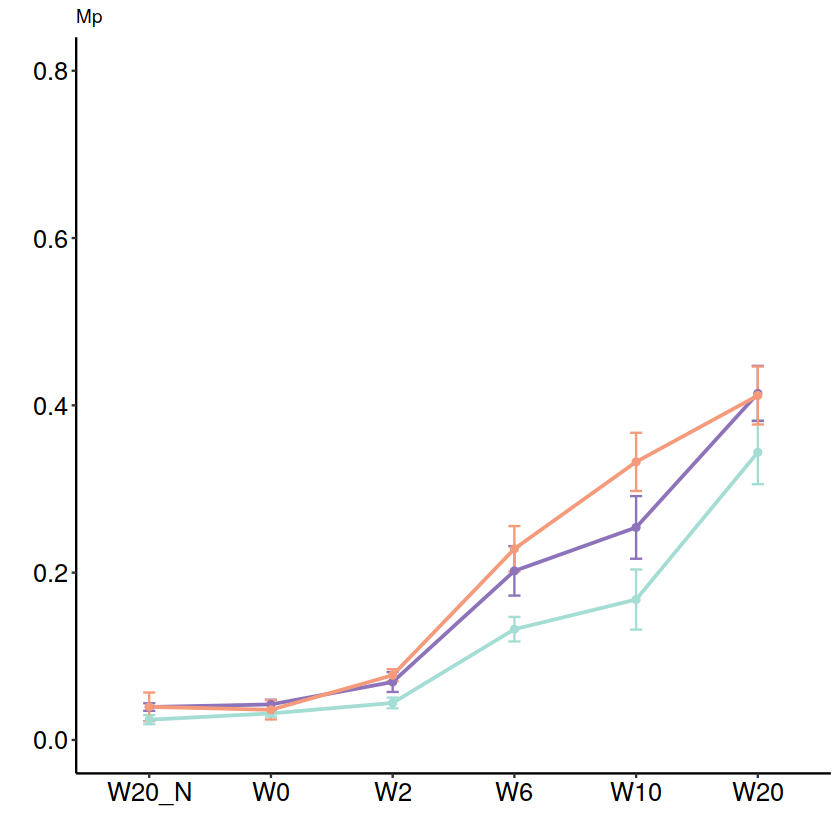

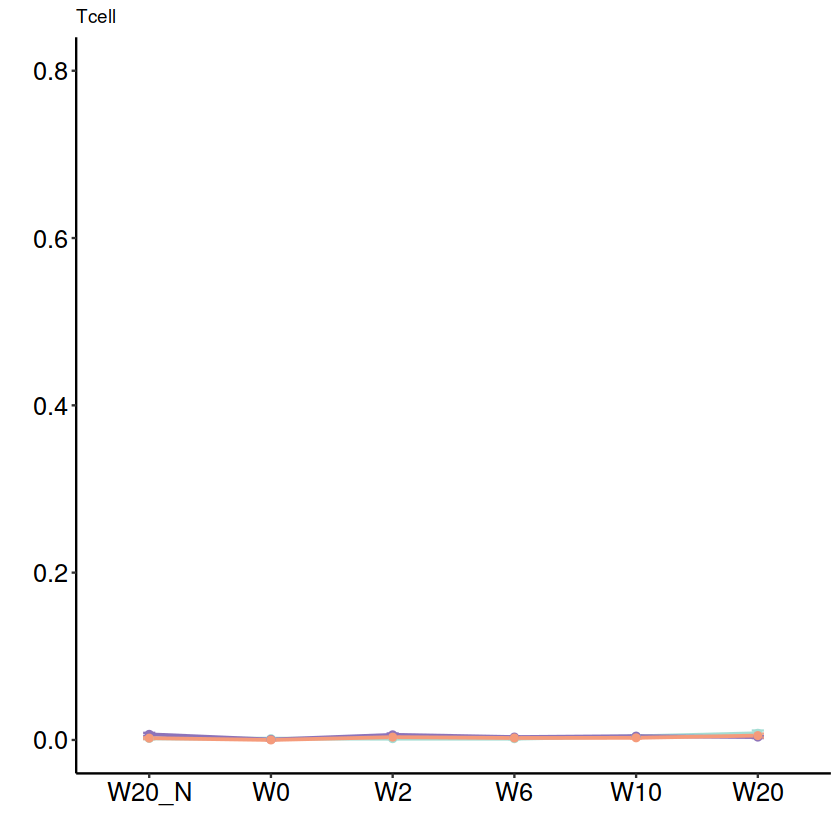

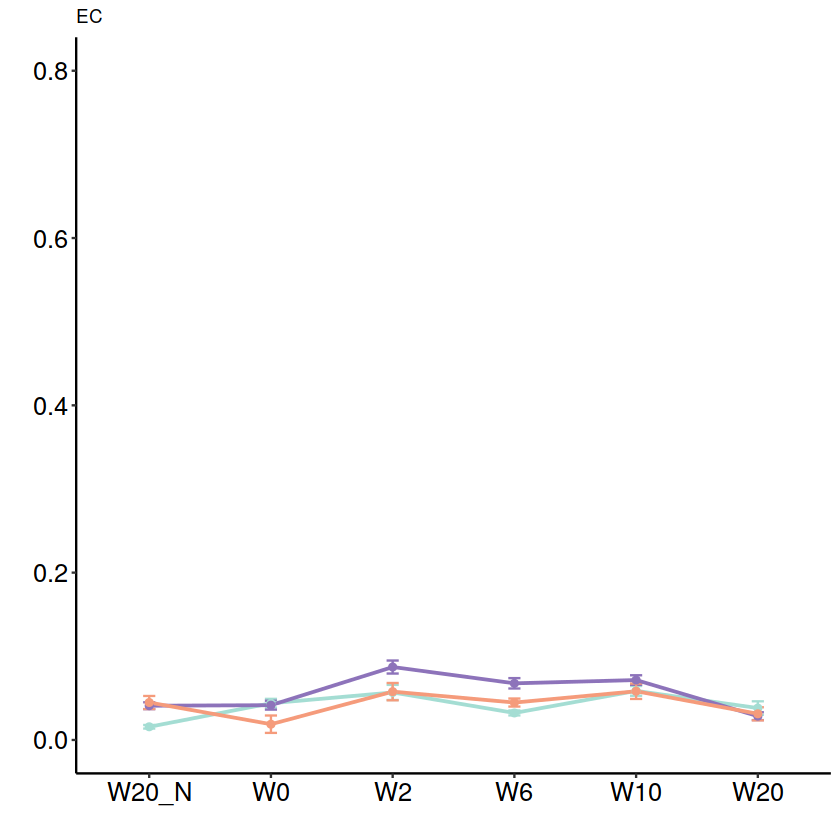

In [68]:
##pdf("cell_line_week_and_AD_se_three_1.pdf",width = 6,height = 5)
print(p+ ylim(0, 0.8))
print(p+ ylim(0, 0.8)+theme(axis.text.x = element_text(size=15,color = "black"),
         axis.text.y = element_text(size=15,color = "black"))+theme(legend.position = "none"))
for(i in cell){
    mer5<-subset(mer4,subset = AD%in%c("GC-AA","GC-AR","LC-AA"))
    mer6 <- subset(mer5,subset = celltype==i) 
    tgc <-summarySE(mer6, measurevar="percent", groupvars=c("week","AD"))
    order <- c("W20_N","W0","W2","W6","W10","W20")
    tgc$week <- factor(tgc$week,levels = order)
    p1 <- ggplot(tgc, aes(x=week, y=percent,color=AD,group=AD)) + 
    geom_errorbar(aes(ymin=percent-se, ymax=percent+se), width=.1) +scale_color_manual(values = cols)+labs(x="",y="",subtitle = i)+
    geom_line(cex=0.8) +geom_point()+theme_classic()+ylim(0, 0.8)+theme(axis.text.x = element_text(size=15,color = "black"),
         axis.text.y = element_text(size=15,color = "black"))+theme(legend.position = "none")
    print(p1)
}
###dev.off()